# RBW Sensor Ranking and Diagnostics

This notebook turns the exploratory `DatasetFM-v0..v3.ipynb` workflow into a more rigorous analysis of `data/RBW_acquisitions`.

**System boundary**
- Domain/core: CSV parsing, integrity summaries, PSD distribution diagnostics, noise-floor recentring, and cumulative-correlation ranking live in `measurement_calibration.sensor_ranking`.
- Application/orchestration: this notebook only configures the analysis, displays tables, and renders figures.
- Side effects: reading acquisition CSV files and generating notebook output cells.

**Evidence blocks carried over from the exploratory notebooks**
1. Dataset integrity checks before any ranking is trusted.
2. Multi-record PSD overlays to verify cross-sensor alignment visually.
3. Whole-campaign PSD distribution diagnostics from `DatasetFM-v0`/`v1`.
4. Record-wise cumulative-correlation ranking from `DatasetFM-v3`.
5. Rank-stability summaries so the final winner is supported by more than a single mean score.

The distribution diagnostics and the record-wise ranking answer different questions. A sensor can have a globally similar PSD-value distribution yet still disagree on record-by-record spectral shape, so both views are reported explicitly.

In [7]:
from __future__ import annotations

import importlib
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def resolve_repo_root() -> Path:
    """Return the repository root regardless of the notebook launch directory."""

    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    for candidate in candidates:
        if (candidate / "measurement_calibration").exists() and (
            candidate / "data"
        ).exists():
            return candidate
    raise RuntimeError(
        "Could not locate the repository root from the current notebook session"
    )


def validate_record_indices(
    n_records: int,  # Number of valid record indices in the selected RBW subset
    requested_indices: tuple[int, ...],  # Record indices requested for visualization
) -> tuple[int, ...]:  # Validated record indices in the original order
    """Validate that each requested record index exists in the dataset."""

    invalid_indices = [
        index for index in requested_indices if not 0 <= index < n_records
    ]
    if invalid_indices:
        raise IndexError(
            f"Requested record indices {invalid_indices} fall outside [0, {n_records - 1}]"
        )
    return requested_indices


def make_sensor_color_map(
    sensor_ids: tuple[str, ...],  # Ordered sensor identifiers
) -> dict[str, tuple[float, float, float, float]]:  # Stable color per sensor
    """Assign stable plotting colors to the selected sensor identifiers."""

    color_map = plt.colormaps["tab10"]
    return {
        sensor_id: color_map(index % 10)
        for index, sensor_id in enumerate(sensor_ids)
    }


def annotate_heatmap(
    ax,
    matrix: np.ndarray,  # Square matrix to draw
    labels: tuple[str, ...],  # Axis labels for rows and columns
    title: str,  # Plot title
    *,
    cmap: str = "viridis",  # Matplotlib colormap name
    vmin: float | None = None,  # Lower color scale bound
    vmax: float | None = None,  # Upper color scale bound
) -> None:  # Draws into the provided axes
    """Render a square heatmap with numeric annotations."""

    image = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_title(title)

    value_span = np.nanmax(matrix) - np.nanmin(matrix)
    midpoint = np.nanmin(matrix) + 0.5 * value_span if np.isfinite(value_span) else 0.0
    for row_index, column_index in np.ndindex(matrix.shape):
        value = matrix[row_index, column_index]
        text_color = "white" if value < midpoint else "black"
        ax.text(
            column_index,
            row_index,
            f"{value:.3f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=9,
        )

    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)


REPO_ROOT = resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Reload the local analysis module so rerunning this cell picks up edits
# without requiring a kernel restart.
import measurement_calibration.sensor_ranking as sensor_ranking_module  # noqa: E402

sensor_ranking_module = importlib.reload(sensor_ranking_module)
build_dataset_summary_rows = sensor_ranking_module.build_dataset_summary_rows
build_distribution_summary_rows = (
    sensor_ranking_module.build_distribution_summary_rows
)
build_rbw_overview_rows = sensor_ranking_module.build_rbw_overview_rows
build_score_stability_rows = sensor_ranking_module.build_score_stability_rows
build_sensor_integrity_rows = sensor_ranking_module.build_sensor_integrity_rows
build_sensor_ranking_rows = sensor_ranking_module.build_sensor_ranking_rows
load_rbw_acquisition_datasets = sensor_ranking_module.load_rbw_acquisition_datasets
rank_sensors_by_cumulative_correlation = (
    sensor_ranking_module.rank_sensors_by_cumulative_correlation
)
summarize_psd_distribution = sensor_ranking_module.summarize_psd_distribution

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.4f}".format

# Notebook configuration. The selected RBW subset is inspected with both the
# dataset-wide histogram diagnostics and the record-wise correlation ranking.
RBW_DATA_ROOT = REPO_ROOT / "data" / "RBW_acquisitions"
SELECTED_RBW = "10K"
SELECTED_RECORD_INDICES = (0, 3, 9)
NOISE_FLOOR_HISTOGRAM_BINS = 50
DISTRIBUTION_HISTOGRAM_BINS = 300
DISTRIBUTION_RANGE_DB: tuple[float, float] | None = None
PLOT_FREQUENCY_WINDOW_MHZ = (97.0, 99.0)

## Load The RBW Campaign Tree

The first pass mirrors the integrity checks from `DatasetFM-v0`: shared record counts, shared frequency grids, sensor-level descriptive statistics, and timestamp spread across sensors. If those checks look wrong, the ranking should not be interpreted.

In [8]:
rbw_datasets = load_rbw_acquisition_datasets(RBW_DATA_ROOT)

dataset_summary = (
    pd.DataFrame(build_dataset_summary_rows(rbw_datasets))
    .sort_values("rbw")
    .reset_index(drop=True)
)
display(dataset_summary)

selected_dataset = rbw_datasets[SELECTED_RBW]
selected_record_indices = validate_record_indices(
    selected_dataset.n_records,
    SELECTED_RECORD_INDICES,
)

selected_sensor_summary = (
    pd.DataFrame(build_sensor_integrity_rows(selected_dataset))
    .sort_values("sensor_id")
    .reset_index(drop=True)
)
display(selected_sensor_summary)

record_time_spread_s = (
    np.max(selected_dataset.timestamps_ms, axis=0)
    - np.min(selected_dataset.timestamps_ms, axis=0)
) / 1_000.0

print(
    f"Selected RBW {SELECTED_RBW}: {selected_dataset.n_sensors} sensors, "
    f"{selected_dataset.n_records} records, "
    f"{selected_dataset.n_frequencies} frequency bins"
)
print(f"Inspected record indices: {selected_record_indices}")
print(
    "Mean timestamp spread across sensors: "
    f"{record_time_spread_s.mean():.3f} s | "
    f"max: {record_time_spread_s.max():.3f} s"
)

,rbw,n_sensors,n_records,n_frequencies,frequency_step_hz,frequency_span_mhz,mean_record_time_spread_s,max_record_time_spread_s,sensor_ids
0,100K,5,29,512,39138.9432,20.0000,3.9511,4.5920,"Node1, Node3, Node4, Node5, Node9"
1,10K,5,60,4096,4884.0049,20.0000,4.1707,5.4280,"Node1, Node3, Node4, Node5, Node9"
2,30K,5,60,1024,19550.3421,20.0000,4.1093,5.2950,"Node1, Node3, Node4, Node5, Node9"
3,3K,5,60,16384,1220.7776,20.0000,4.2340,5.2760,"Node1, Node3, Node4, Node5, Node9"


,sensor_id,records,timestamp_start_ms,timestamp_end_ms,acquisition_span_s,mean_psd_db,std_psd_db,min_psd_db,max_psd_db
0,Node1,60,1772856615634,1772863695784,7080.1500,-57.7785,9.7065,-67.8333,-19.7929
1,Node3,60,1772856615437,1772863695668,7080.2310,-55.3664,9.6190,-64.7929,-16.6280
2,Node4,60,1772856617556,1772863697171,7079.6150,-60.7441,8.0720,-68.9776,-24.6054
3,Node5,60,1772856619062,1772863699452,7080.3900,-54.1479,10.6325,-65.2322,-13.4179
4,Node9,60,1772856617214,1772863697954,7080.7400,-54.3434,8.8003,-63.1517,-20.7503


Selected RBW 10K: 5 sensors, 60 records, 4096 frequency bins
Inspected record indices: (0, 3, 9)
Mean timestamp spread across sensors: 4.171 s | max: 5.428 s


## Inspect Several Aligned Records

The exploratory notebooks checked several rows before trusting the metric. The overlays below answer the same question here: are the sensors observing the same FM scene closely enough that a row-wise comparison is meaningful?

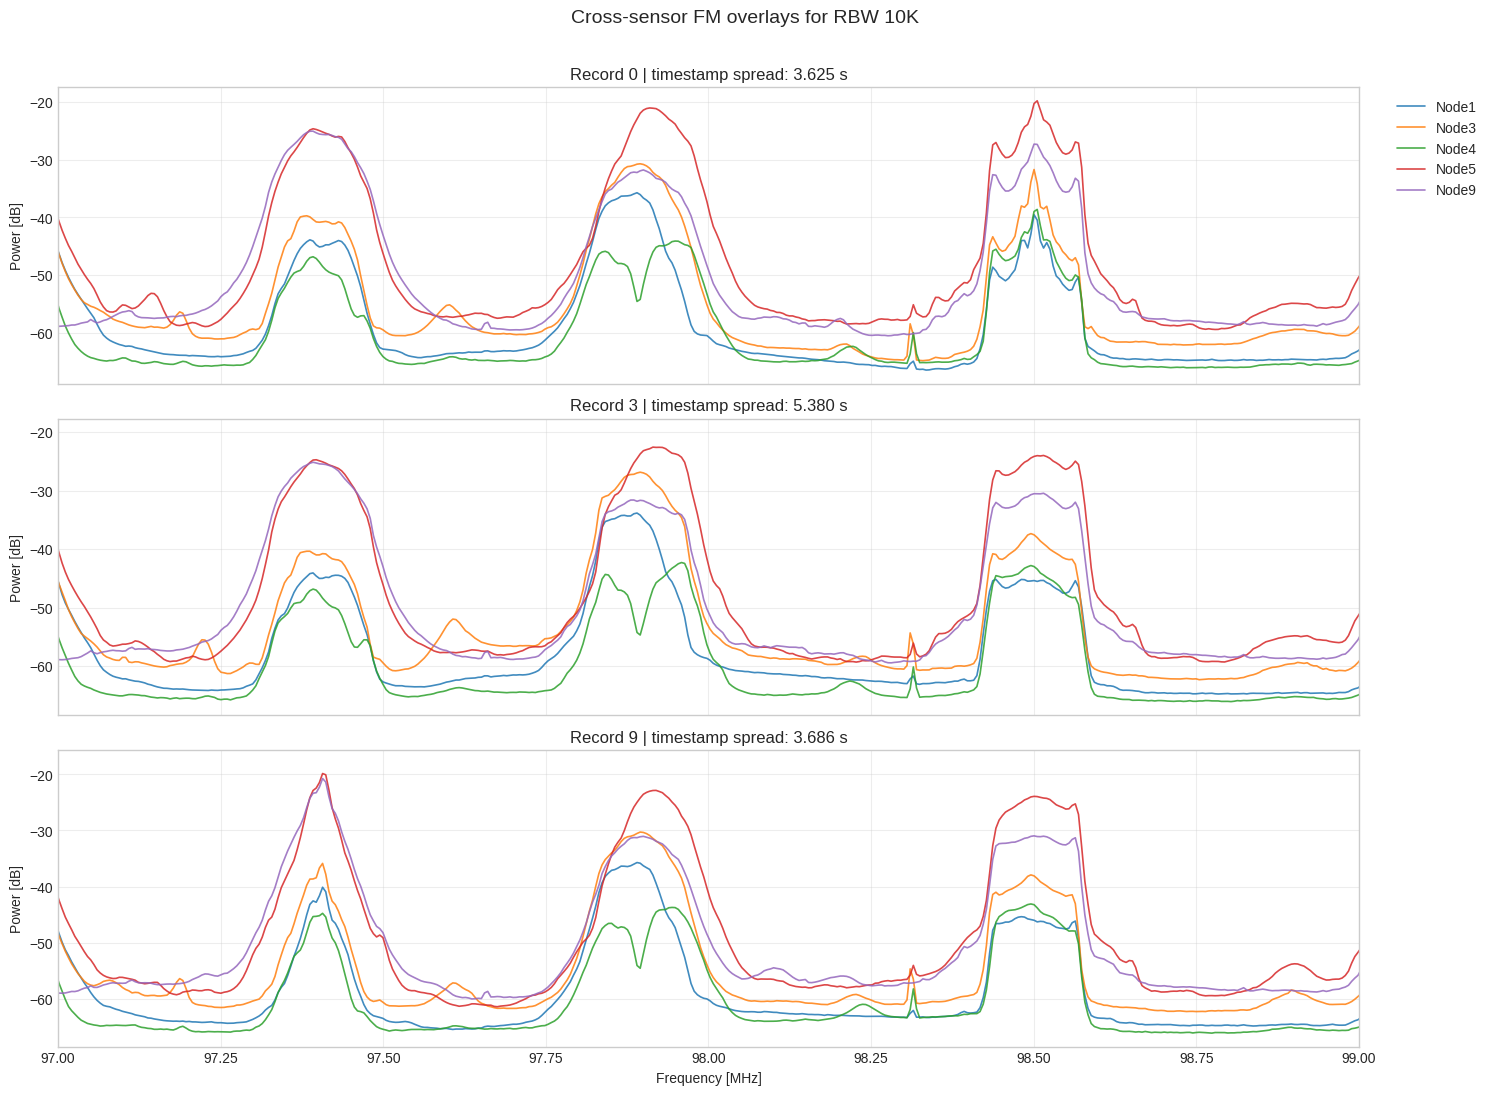

In [9]:
selected_frequency_mhz = selected_dataset.frequency_hz / 1.0e6
sensor_to_color = make_sensor_color_map(selected_dataset.sensor_ids)

fig, axes = plt.subplots(
    len(selected_record_indices),
    1,
    figsize=(15, 3.6 * len(selected_record_indices)),
    sharex=True,
)
if len(selected_record_indices) == 1:
    axes = [axes]

for ax, record_index in zip(axes, selected_record_indices):
    record_panel_db = selected_dataset.observations_db[:, record_index, :]
    record_spread_s = (
        np.max(selected_dataset.timestamps_ms[:, record_index])
        - np.min(selected_dataset.timestamps_ms[:, record_index])
    ) / 1_000.0

    for sensor_id, power_db in zip(
        selected_dataset.sensor_ids,
        record_panel_db,
        strict=True,
    ):
        ax.plot(
            selected_frequency_mhz,
            power_db,
            label=sensor_id,
            linewidth=1.2,
            alpha=0.85,
            color=sensor_to_color[sensor_id],
        )

    ax.set_title(
        f"Record {record_index} | timestamp spread: {record_spread_s:.3f} s"
    )
    ax.set_ylabel("Power [dB]")
    ax.grid(True, alpha=0.35)
    if PLOT_FREQUENCY_WINDOW_MHZ is not None:
        ax.set_xlim(PLOT_FREQUENCY_WINDOW_MHZ)

axes[0].legend(bbox_to_anchor=(1.02, 1.0), loc="upper left")
axes[-1].set_xlabel("Frequency [MHz]")
fig.suptitle(
    f"Cross-sensor FM overlays for RBW {SELECTED_RBW}",
    fontsize=14,
    y=1.01,
)
plt.tight_layout()
plt.show()

## Dataset-Wide PSD Distribution Diagnostics

This section reproduces the histogram-shape analysis from `DatasetFM-v0` and `DatasetFM-v1`. It does **not** measure record-by-record agreement. Instead, it checks whether each sensor contributes a similar overall PSD-value distribution across the full campaign.

,rank,sensor_id,distribution_similarity,normalized_similarity,mean_psd_db,std_psd_db,min_psd_db,max_psd_db,value_count,is_low_similarity_outlier
0,1,Node5,1.9946,0.4986,-54.1479,10.6325,-65.2322,-13.4179,245760,False
1,2,Node3,1.5966,0.3992,-55.3664,9.6190,-64.7929,-16.6280,245760,False
2,3,Node9,1.3446,0.3361,-54.3434,8.8003,-63.1517,-20.7503,245760,False
3,4,Node1,1.1799,0.2950,-57.7785,9.7065,-67.8333,-19.7929,245760,False
4,5,Node4,0.3306,0.0827,-60.7441,8.0720,-68.9776,-24.6054,245760,True


/tmp/ipykernel_68497/3615135921.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


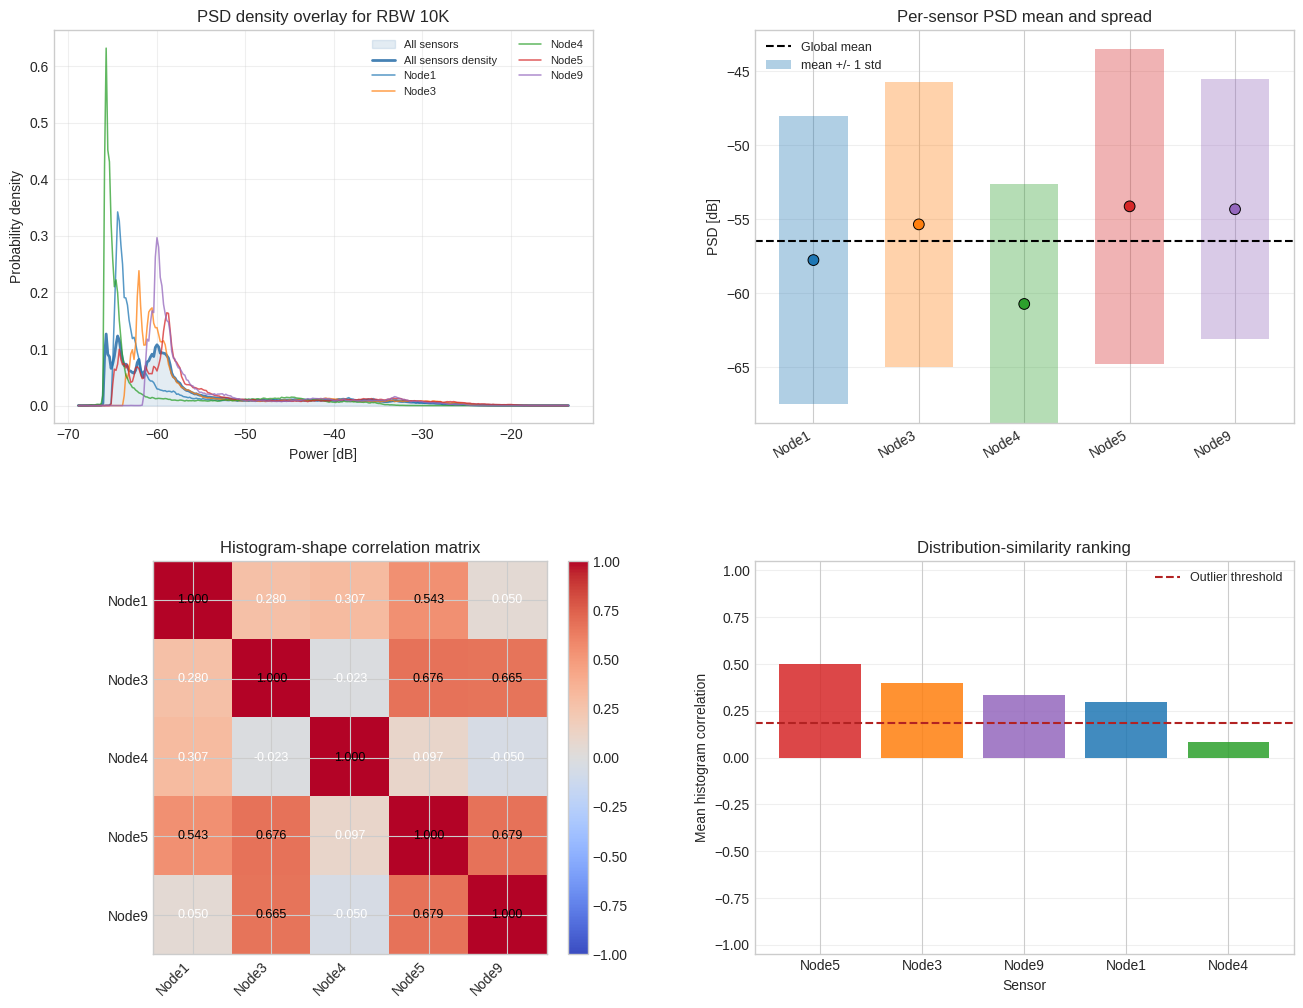

In [10]:
selected_distribution = summarize_psd_distribution(
    selected_dataset,
    histogram_bins=DISTRIBUTION_HISTOGRAM_BINS,
    value_range_db=DISTRIBUTION_RANGE_DB,
)
selected_distribution_table = (
    pd.DataFrame(build_distribution_summary_rows(selected_distribution))
    .sort_values("rank")
    .reset_index(drop=True)
)
display(selected_distribution_table)

sensor_to_color = make_sensor_color_map(selected_distribution.sensor_ids)
ordered_distribution_table = selected_distribution_table.sort_values("rank")
threshold_normalized = (
    selected_distribution.outlier_threshold / (selected_dataset.n_sensors - 1)
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 12),
    gridspec_kw={"hspace": 0.35, "wspace": 0.30},
)

# Panel A: global PSD density plus the per-sensor density curves.
ax = axes[0, 0]
ax.fill_between(
    selected_distribution.bin_centers_db,
    selected_distribution.global_density,
    color="steelblue",
    alpha=0.15,
    label="All sensors",
)
ax.plot(
    selected_distribution.bin_centers_db,
    selected_distribution.global_density,
    color="steelblue",
    linewidth=2.0,
    label="All sensors density",
)
for sensor_index, sensor_id in enumerate(selected_distribution.sensor_ids):
    ax.plot(
        selected_distribution.bin_centers_db,
        selected_distribution.per_sensor_density[sensor_index],
        linewidth=1.1,
        alpha=0.75,
        color=sensor_to_color[sensor_id],
        label=sensor_id,
    )
ax.set_title(f"PSD density overlay for RBW {SELECTED_RBW}")
ax.set_xlabel("Power [dB]")
ax.set_ylabel("Probability density")
ax.grid(True, alpha=0.30)
ax.legend(fontsize=8, ncol=2)

# Panel B: mean +/- 1 sigma per sensor to expose global offsets/spread.
ax = axes[0, 1]
x_positions = np.arange(len(selected_distribution.sensor_ids))
means_db = selected_distribution.mean_db
std_db = selected_distribution.std_db
colors = [sensor_to_color[sensor_id] for sensor_id in selected_distribution.sensor_ids]
ax.bar(
    x_positions,
    2.0 * std_db,
    bottom=means_db - std_db,
    alpha=0.35,
    color=colors,
    width=0.65,
    label="mean +/- 1 std",
)
ax.scatter(
    x_positions,
    means_db,
    color=colors,
    edgecolors="black",
    linewidths=0.7,
    s=60,
    zorder=3,
)
ax.axhline(
    float(np.mean(means_db)),
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Global mean",
)
ax.set_xticks(x_positions)
ax.set_xticklabels(selected_distribution.sensor_ids, rotation=30, ha="right")
ax.set_ylabel("PSD [dB]")
ax.set_title("Per-sensor PSD mean and spread")
ax.grid(True, axis="y", alpha=0.30)
ax.legend(fontsize=9)

annotate_heatmap(
    axes[1, 0],
    selected_distribution.correlation_matrix,
    selected_distribution.sensor_ids,
    "Histogram-shape correlation matrix",
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
)

ax = axes[1, 1]
ax.bar(
    ordered_distribution_table["sensor_id"],
    ordered_distribution_table["normalized_similarity"],
    color=[sensor_to_color[sensor_id] for sensor_id in ordered_distribution_table["sensor_id"]],
    alpha=0.85,
)
ax.axhline(
    threshold_normalized,
    color="firebrick",
    linestyle="--",
    linewidth=1.5,
    label="Outlier threshold",
)
ax.set_ylim(-1.05, 1.05)
ax.set_xlabel("Sensor")
ax.set_ylabel("Mean histogram correlation")
ax.set_title("Distribution-similarity ranking")
ax.grid(True, axis="y", alpha=0.30)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

if selected_distribution.clipped_fraction > 0.0:
    print(
        "Histogram clipping fraction: "
        f"{100.0 * selected_distribution.clipped_fraction:.2f}%"
    )

## Record-Wise Cumulative Correlation Ranking

This is the `DatasetFM-v3` metric promoted to the reusable module. Every record is processed independently after histogram-mode noise-floor recentring, so the winner can be checked both by its average score and by how consistently it finishes first.

In [11]:
selected_ranking = rank_sensors_by_cumulative_correlation(
    selected_dataset,
    histogram_bins=NOISE_FLOOR_HISTOGRAM_BINS,
)
selected_ranking_table = (
    pd.DataFrame(build_sensor_ranking_rows(selected_ranking))
    .sort_values("rank")
    .reset_index(drop=True)
)
selected_stability_table = (
    pd.DataFrame(build_score_stability_rows(selected_ranking))
    .sort_values("rank")
    .reset_index(drop=True)
)

print(
    "Distribution winner: "
    f"{selected_distribution.ranking_sensor_ids[0]} | "
    "record-wise winner: "
    f"{selected_ranking.ranking_sensor_ids[0]}"
)
if selected_distribution.ranking_sensor_ids[0] != selected_ranking.ranking_sensor_ids[0]:
    print(
        "The two winners differ because the histogram diagnostic measures "
        "campaign-wide PSD-value similarity, while the ranking measures "
        "record-by-record spectral agreement after recentring."
    )

display(selected_ranking_table)
display(selected_stability_table)

Distribution winner: Node5 | record-wise winner: Node3
The two winners differ because the histogram diagnostic measures campaign-wide PSD-value similarity, while the ranking measures record-by-record spectral agreement after recentring.


,rank,sensor_id,mean_score,mean_correlation,score_std,mean_noise_floor_db,records
0,1,Node3,3.5959,0.8990,0.0109,-61.6048,60
1,2,Node1,3.5734,0.8933,0.0108,-64.5036,60
2,3,Node4,3.5624,0.8906,0.0103,-66.0136,60
3,4,Node5,3.4948,0.8737,0.0101,-59.5083,60
4,5,Node9,3.2864,0.8216,0.0126,-60.0362,60


,rank,sensor_id,mean_score,mean_correlation,score_std,score_min,score_max,mean_rank,best_rank,worst_rank,top_1_count,top_1_fraction
0,1,Node3,3.5959,0.8990,0.0109,3.5445,3.6136,1.0333,1,2,58,0.9667
1,2,Node1,3.5734,0.8933,0.0108,3.5265,3.5943,2.0833,1,3,1,0.0167
2,3,Node4,3.5624,0.8906,0.0103,3.5252,3.5858,2.8833,1,3,1,0.0167
3,4,Node5,3.4948,0.8737,0.0101,3.4689,3.5154,4.0000,4,4,0,0.0000
4,5,Node9,3.2864,0.8216,0.0126,3.2614,3.3245,5.0000,5,5,0,0.0000


/tmp/ipykernel_68497/3656687100.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


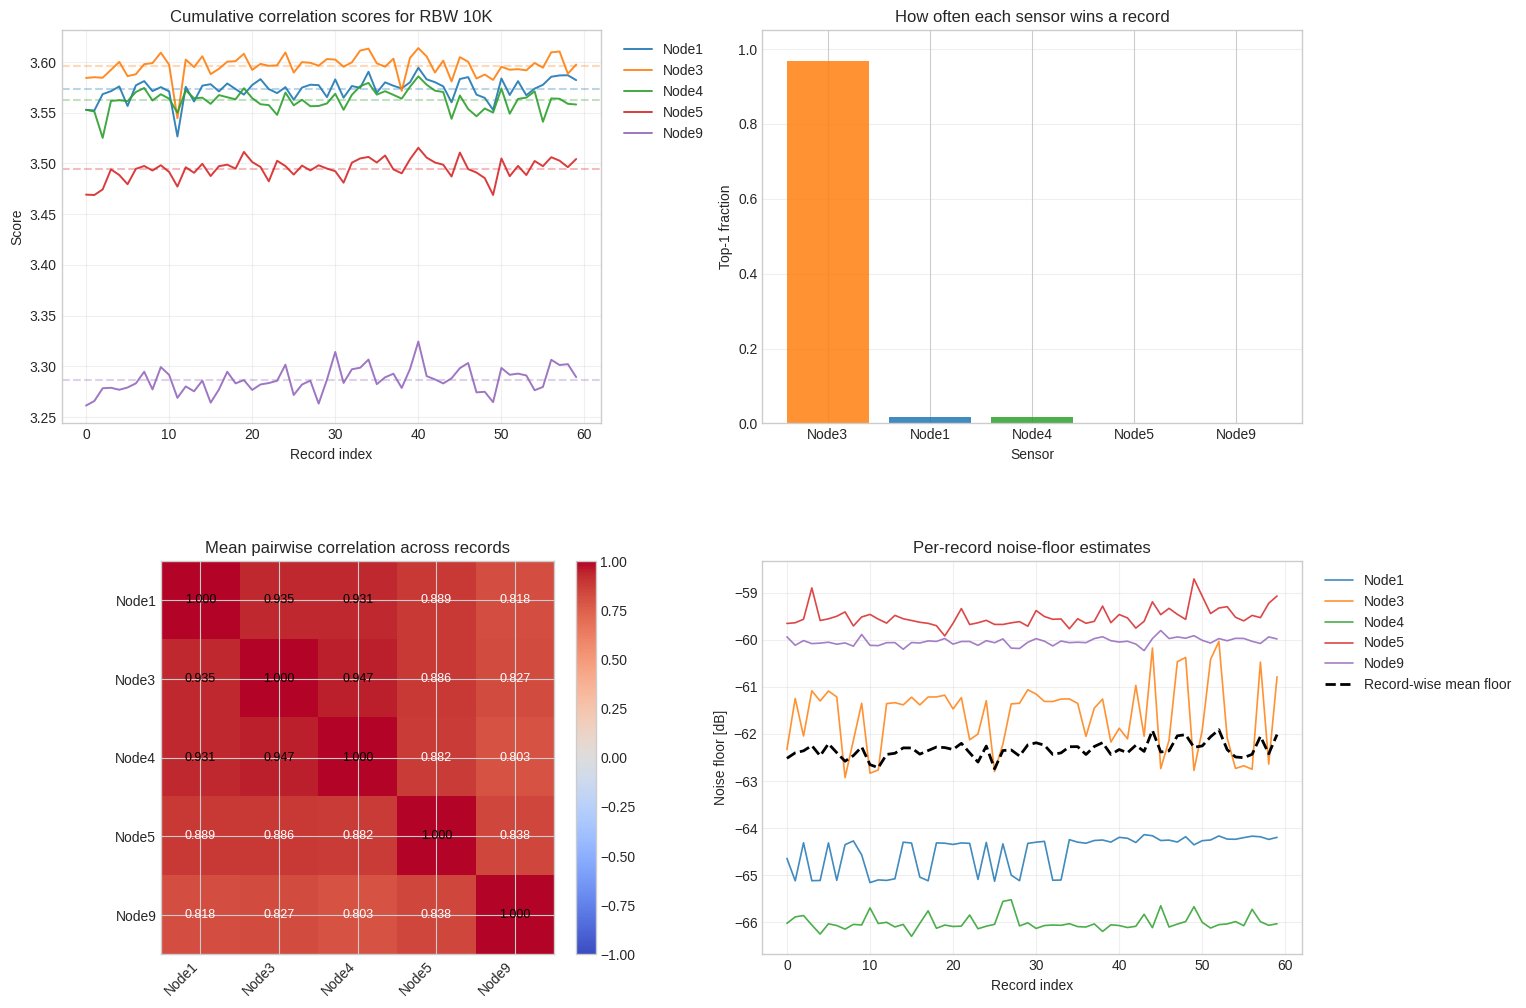

In [12]:
sensor_to_color = make_sensor_color_map(selected_ranking.sensor_ids)
record_index = np.arange(selected_dataset.n_records)
ordered_stability_table = selected_stability_table.sort_values("rank")
mean_pairwise_correlation = np.mean(selected_ranking.per_record_correlation, axis=0)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 12),
    gridspec_kw={"hspace": 0.35, "wspace": 0.30},
)

# Panel A: per-record cumulative scores with each sensor's mean score.
ax = axes[0, 0]
for sensor_index, sensor_id in enumerate(selected_ranking.sensor_ids):
    score_series = selected_ranking.per_record_score[sensor_index]
    mean_score = selected_ranking.average_score[sensor_index]
    ax.plot(
        record_index,
        score_series,
        label=sensor_id,
        color=sensor_to_color[sensor_id],
        linewidth=1.4,
        alpha=0.9,
    )
    ax.axhline(
        mean_score,
        color=sensor_to_color[sensor_id],
        linestyle="--",
        alpha=0.30,
    )
ax.set_title(f"Cumulative correlation scores for RBW {SELECTED_RBW}")
ax.set_xlabel("Record index")
ax.set_ylabel("Score")
ax.grid(True, alpha=0.30)
ax.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left")

# Panel B: top-1 fraction reveals how often the winner actually wins.
ax = axes[0, 1]
ax.bar(
    ordered_stability_table["sensor_id"],
    ordered_stability_table["top_1_fraction"],
    color=[sensor_to_color[sensor_id] for sensor_id in ordered_stability_table["sensor_id"]],
    alpha=0.85,
)
ax.set_ylim(0.0, 1.05)
ax.set_xlabel("Sensor")
ax.set_ylabel("Top-1 fraction")
ax.set_title("How often each sensor wins a record")
ax.grid(True, axis="y", alpha=0.30)

annotate_heatmap(
    axes[1, 0],
    mean_pairwise_correlation,
    selected_ranking.sensor_ids,
    "Mean pairwise correlation across records",
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
)

# Panel D: the global mean floor shows the target used to recenter each record.
ax = axes[1, 1]
for sensor_index, sensor_id in enumerate(selected_ranking.sensor_ids):
    ax.plot(
        record_index,
        selected_ranking.noise_floor_db[sensor_index],
        label=sensor_id,
        color=sensor_to_color[sensor_id],
        linewidth=1.2,
        alpha=0.85,
    )
ax.plot(
    record_index,
    selected_ranking.global_noise_floor_db,
    color="black",
    linestyle="--",
    linewidth=2.0,
    label="Record-wise mean floor",
)
ax.set_title("Per-record noise-floor estimates")
ax.set_xlabel("Record index")
ax.set_ylabel("Noise floor [dB]")
ax.grid(True, alpha=0.30)
ax.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left")

plt.tight_layout()
plt.show()

## Compare Every RBW Subset

The final table keeps the practical question explicit: which sensor is the best reference candidate at each RBW, how stable is that winner, and does the dataset-wide histogram view agree with the record-wise ranking?

In [13]:
ranking_results_by_rbw = {
    rbw_label: rank_sensors_by_cumulative_correlation(
        dataset,
        histogram_bins=NOISE_FLOOR_HISTOGRAM_BINS,
    )
    for rbw_label, dataset in sorted(rbw_datasets.items())
}
distribution_results_by_rbw = {
    rbw_label: summarize_psd_distribution(
        dataset,
        histogram_bins=DISTRIBUTION_HISTOGRAM_BINS,
        value_range_db=DISTRIBUTION_RANGE_DB,
    )
    for rbw_label, dataset in sorted(rbw_datasets.items())
}

rbw_overview = pd.DataFrame(build_rbw_overview_rows(ranking_results_by_rbw))
stability_overview = pd.DataFrame(
    [
        {
            "rbw": rbw_label,
            "best_top_1_fraction": float(stability_table.iloc[0]["top_1_fraction"]),
            "mean_score_gap_to_second": float(
                ranking_table.iloc[0]["mean_score"] - ranking_table.iloc[1]["mean_score"]
            ),
        }
        for rbw_label, result in sorted(ranking_results_by_rbw.items())
        for ranking_table in [
            pd.DataFrame(build_sensor_ranking_rows(result))
            .sort_values("rank")
            .reset_index(drop=True)
        ]
        for stability_table in [
            pd.DataFrame(build_score_stability_rows(result))
            .sort_values("rank")
            .reset_index(drop=True)
        ]
    ]
)
distribution_overview = pd.DataFrame(
    [
        {
            "rbw": rbw_label,
            "distribution_best_sensor_id": diagnostics.ranking_sensor_ids[0],
            "distribution_best_similarity": float(
                np.max(diagnostics.normalized_similarity_score)
            ),
        }
        for rbw_label, diagnostics in sorted(distribution_results_by_rbw.items())
    ]
)

cross_metric_overview = (
    rbw_overview
    .merge(stability_overview, on="rbw")
    .merge(distribution_overview, on="rbw")
    .sort_values("rbw")
    .reset_index(drop=True)
)
cross_metric_overview["metrics_agree"] = (
    cross_metric_overview["best_sensor_id"]
    == cross_metric_overview["distribution_best_sensor_id"]
)
display(cross_metric_overview)

recordwise_best_counts = (
    cross_metric_overview["best_sensor_id"]
    .value_counts()
    .rename_axis("sensor_id")
    .reset_index(name="recordwise_best_rbw_count")
)
distribution_best_counts = (
    cross_metric_overview["distribution_best_sensor_id"]
    .value_counts()
    .rename_axis("sensor_id")
    .reset_index(name="distribution_best_rbw_count")
)
display(recordwise_best_counts)
display(distribution_best_counts)

,rbw,best_sensor_id,best_mean_score,best_mean_correlation,n_sensors,n_records,best_top_1_fraction,mean_score_gap_to_second,distribution_best_sensor_id,distribution_best_similarity,metrics_agree
0,100K,Node1,3.6051,0.9013,5,29,0.4828,0.0048,Node5,0.4747,False
1,10K,Node3,3.5959,0.8990,5,60,0.9667,0.0225,Node5,0.4986,False
2,30K,Node3,3.6267,0.9067,5,60,0.8667,0.0148,Node5,0.4583,False
3,3K,Node3,3.4995,0.8749,5,60,1.0000,0.0827,Node5,0.5565,False


,sensor_id,recordwise_best_rbw_count
0,Node3,3
1,Node1,1


,sensor_id,distribution_best_rbw_count
0,Node5,4
